# Numerical Stability and Second-Order Sections

This notebook investigates numerical stability problems that can occur in high-order IIR filters and examines how second-order sections (SOS) provide a more numerically robust implementation.

## Objective

The objectives of this notebook are to:

- Understand why high-order IIR filters can suffer from numerical problems.
- Compare the transfer function and second-order section representations of the same filter.
- Observe how numerical errors can affect frequency response and time-domain filtering.
- Understand the role of pole locations in filter stability.
- Examine why SOS is preferred for practical implementation of high-order IIR filters.

## Theory

### Numerical Stability in IIR Filters

An IIR filter can be represented using numerator and denominator polynomials:

$$
H(z) =
\frac{b_0 + b_1z^{-1} + \cdots + b_Mz^{-M}}
{a_0 + a_1z^{-1} + \cdots + a_Nz^{-N}}
$$

This is commonly called the transfer function or direct-form representation.

For high-order filters, the polynomial coefficients can become sensitive to numerical precision. Small errors in these coefficients can produce significant changes in the calculated pole locations and filter response.

### Stability and Pole Locations

For a discrete-time IIR filter to be stable, its poles must lie inside the unit circle:

$$
|p_i| < 1
$$

A pole close to the unit circle can already make a system sensitive to numerical errors.

### Second-Order Sections

Instead of implementing a high-order filter as one large polynomial, it can be represented as a cascade of second-order filters:

$$
H(z) = G
\prod_{k=1}^{K}
\frac{
b_{0,k}+b_{1,k}z^{-1}+b_{2,k}z^{-2}
}{
1+a_{1,k}z^{-1}+a_{2,k}z^{-2}
}
$$

Each second-order section contains at most two poles and two zeros.

This structure is commonly called a biquad or second-order section (SOS).

The complete filter can therefore be implemented as a cascade of lower-order sections instead of one high-order polynomial.

## Experiment 1: Low-Order Filter in Transfer Function and SOS Forms

First, design a low-order Butterworth filter using both transfer function (`ba`) and second-order section (`sos`) representations.

At a relatively low order, compare the two implementations to establish a baseline before investigating high-order filters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Sampling frequency
fs = 1000  # Hz

# Low-order filter
order = 4
cutoff = 100  # Hz

# Transfer function representation
b, a = signal.butter(
    N=order,
    Wn=cutoff,
    btype="lowpass",
    fs=fs,
    output="ba"
)

# Second-order section representation
sos = signal.butter(
    N=order,
    Wn=cutoff,
    btype="lowpass",
    fs=fs,
    output="sos"
)

print("Transfer function:")
print("b =", b)
print("a =", a)

print("\nSOS representation:")
print(sos)

Transfer function:
b = [0.00482434 0.01929737 0.02894606 0.01929737 0.00482434]
a = [ 1.         -2.36951301  2.31398841 -1.05466541  0.18737949]

SOS representation:
[[ 0.00482434  0.00964869  0.00482434  1.         -1.04859958  0.29614036]
 [ 1.          2.          1.          1.         -1.32091343  0.63273879]]


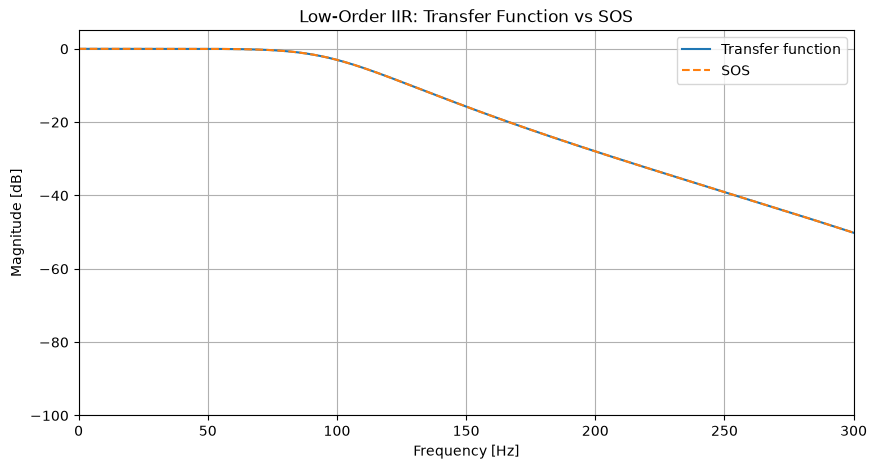

In [2]:
# Frequency response comparison
f_ba, h_ba = signal.freqz(
    b,
    a,
    fs=fs
)

f_sos, h_sos = signal.sosfreqz(
    sos,
    fs=fs
)

plt.figure(figsize=(10, 5))

plt.plot(
    f_ba,
    20 * np.log10(np.maximum(np.abs(h_ba), 1e-12)),
    label="Transfer function"
)

plt.plot(
    f_sos,
    20 * np.log10(np.maximum(np.abs(h_sos), 1e-12)),
    "--",
    label="SOS"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Low-Order IIR: Transfer Function vs SOS")
plt.xlim(0, 300)
plt.ylim(-100, 5)
plt.grid()
plt.legend()
plt.show()

### Observation

- The two representations do not produce noticeably different frequency responses.
- The curves overlap very closely.
- SOS is not significanly more effective when numerical difficulties are not significant.

## Experiment 2: High-Order IIR Frequency Response

Increase the filter order substantially and compare the transfer function and SOS representations of the same Butterworth filter.

The purpose is to observe whether the agreement seen in the previous experiment is preserved at high order.

In [3]:
# High-order Butterworth filter
high_order = 40

b_high, a_high = signal.butter(
    N=high_order,
    Wn=cutoff,
    btype="lowpass",
    fs=fs,
    output="ba"
)

sos_high = signal.butter(
    N=high_order,
    Wn=cutoff,
    btype="lowpass",
    fs=fs,
    output="sos"
)

print("Filter order:", high_order)
print("Number of SOS sections:", sos_high.shape[0])

Filter order: 40
Number of SOS sections: 20


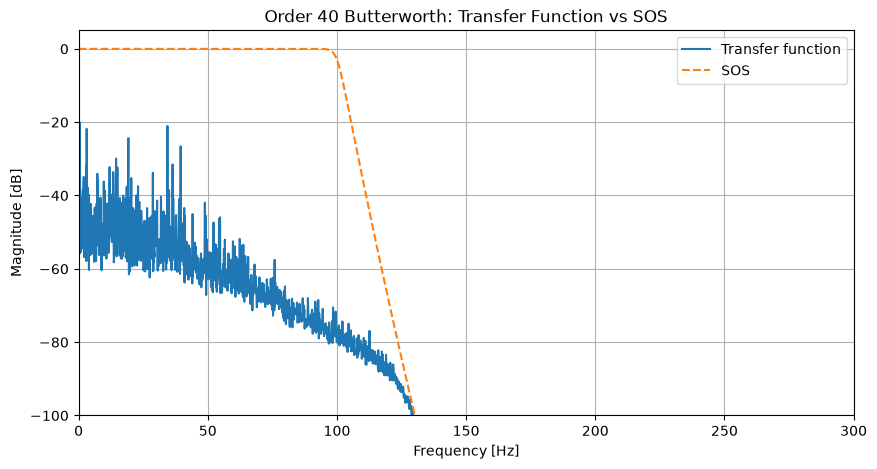

In [4]:
# Frequency response
f_ba_high, h_ba_high = signal.freqz(
    b_high,
    a_high,
    worN=4000,
    fs=fs
)

f_sos_high, h_sos_high = signal.sosfreqz(
    sos_high,
    worN=4000,
    fs=fs
)

plt.figure(figsize=(10, 5))

plt.plot(
    f_ba_high,
    20 * np.log10(np.maximum(np.abs(h_ba_high), 1e-12)),
    label="Transfer function"
)

plt.plot(
    f_sos_high,
    20 * np.log10(np.maximum(np.abs(h_sos_high), 1e-12)),
    "--",
    label="SOS"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title(f"Order {high_order} Butterworth: Transfer Function vs SOS")
plt.xlim(0, 300)
plt.ylim(-100, 5)
plt.grid()
plt.legend()
plt.show()

### Observation

- The two representations do not agree anymore.
- In both passband and stopband, their responses differ very significantly.
- SOS representation appears more reliable for the high-order filter due to having way sharper and smoother results.
- This result is very interesting considering that both representations describe the same filter.

## Experiment 3: High-Order Impulse Response

Use an impulse signal to examine the time-domain response of the high-order filter.

The impulse response is particularly useful for revealing numerical instability because an unstable numerical implementation can produce a rapidly growing output even when the intended filter is stable.

In [5]:
# Unit impulse
n_samples = 500
x_impulse = signal.unit_impulse(n_samples)

# Filter using transfer function form
y_ba = signal.lfilter(
    b_high,
    a_high,
    x_impulse
)

# Filter using SOS form
y_sos = signal.sosfilt(
    sos_high,
    x_impulse
)

print("Maximum absolute value:")
print(f"Transfer function: {np.max(np.abs(y_ba)):.3e}")
print(f"SOS:              {np.max(np.abs(y_sos)):.3e}")

Maximum absolute value:
Transfer function: 7.273e+32
SOS:              1.407e-01


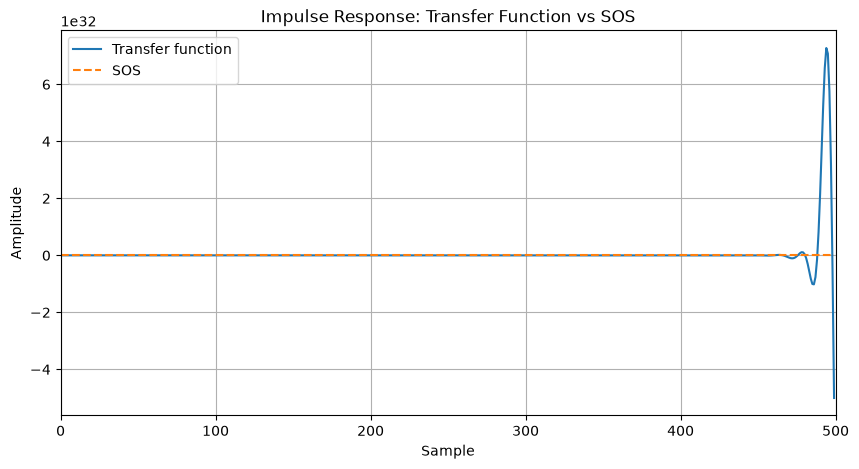

In [6]:
plt.figure(figsize=(10, 5))

n = np.arange(n_samples)

plt.plot(
    n,
    y_ba,
    label="Transfer function"
)

plt.plot(
    n,
    y_sos,
    "--",
    label="SOS"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Impulse Response: Transfer Function vs SOS")
plt.xlim(0, 500)
plt.grid()
plt.legend()
plt.show()

### Observation

- As the sample number increases, SOS remain stable but transfer function becomes unstable at one point.
- The result suggests that a filter may produce unstable results even if it is theoretically stable.

## Experiment 4: Pole Locations and Numerical Stability

Calculate the poles of the high-order filter from the transfer function representation and compare them with the poles obtained from the SOS representation.

For a stable digital filter, poles should remain inside the unit circle.

The comparison illustrates how numerical errors in high-order polynomial representations can affect the calculated pole locations.

In [9]:
# Poles calculated from the transfer function coefficients
poles_ba = np.roots(a_high)

# Poles calculated independently from each SOS section
poles_sos = []

for section in sos_high:
    a_section = section[3:]  # [a0, a1, a2]
    section_poles = np.roots(a_section)

    poles_sos.extend(section_poles)

poles_sos = np.array(poles_sos)

print("Maximum pole magnitude")
print(f"Transfer function: {np.max(np.abs(poles_ba)):.6f}")
print(f"SOS:              {np.max(np.abs(poles_sos)):.6f}")

Maximum pole magnitude
Transfer function: 1.287384
SOS:              0.977184


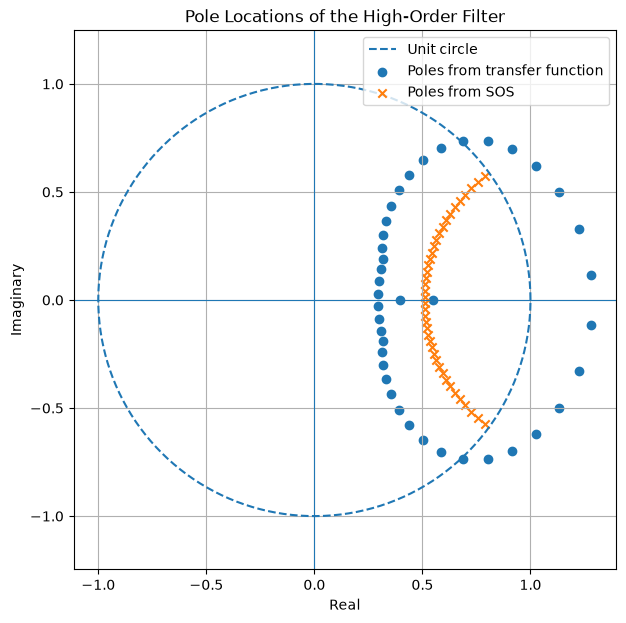

In [10]:
plt.figure(figsize=(7, 7))

# Unit circle
theta = np.linspace(0, 2 * np.pi, 500)

plt.plot(
    np.cos(theta),
    np.sin(theta),
    linestyle="--",
    label="Unit circle"
)

plt.scatter(
    np.real(poles_ba),
    np.imag(poles_ba),
    label="Poles from transfer function"
)

plt.scatter(
    np.real(poles_sos),
    np.imag(poles_sos),
    marker="x",
    label="Poles from SOS"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Pole Locations of the High-Order Filter")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

### Observation

- All poles from SOS representation located inside the unit circle meanwhile some TF poles overflowed outside the circle.
- The two representations produce different pole locations.
- Such a small numerical change may explain the behavior observed in Experiment 3 because the small errors chain and exponentially grow at higher order filters.

## Experiment 5: Inspecting the Second-Order Sections

Inspect the SOS representation of the high-order filter.

Each row represents one second-order section containing numerator and denominator coefficients.

Determine how many sections are required and examine the pole magnitudes of the individual sections.

In [11]:
print("SOS shape:", sos_high.shape)
print("\nEach row represents:")
print("[b0, b1, b2, a0, a1, a2]")

print("\nSOS coefficients:")
print(sos_high)

SOS shape: (20, 6)

Each row represents:
[b0, b1, b2, a0, a1, a2]

SOS coefficients:
[[ 8.26948863e-24  1.65389773e-23  8.26948863e-24  1.00000000e+00
  -1.01934182e+00  2.59975786e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.02167251e+00  2.62856675e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.02635147e+00  2.68640191e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.03341408e+00  2.77370053e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.04291388e+00  2.89112452e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.05492320e+00  3.03956783e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.06953391e+00  3.22016619e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.08685846e+00  3.43430940e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.10703101e+00  3.68365581e-01]
 [ 1.0

In [12]:
# Get poles of each SOS section
section_pole_magnitudes = []

for section in sos_high:
    poles = np.roots(section[3:])
    section_pole_magnitudes.append(np.abs(poles))

section_pole_magnitudes = np.array(section_pole_magnitudes)

for i, magnitudes in enumerate(section_pole_magnitudes, start=1):
    print(
        f"Section {i}: "
        f"pole magnitudes = {magnitudes[0]:.6f}, "
        f"{magnitudes[1]:.6f}"
    )

Section 1: pole magnitudes = 0.509878, 0.509878
Section 2: pole magnitudes = 0.512695, 0.512695
Section 3: pole magnitudes = 0.518305, 0.518305
Section 4: pole magnitudes = 0.526659, 0.526659
Section 5: pole magnitudes = 0.537692, 0.537692
Section 6: pole magnitudes = 0.551323, 0.551323
Section 7: pole magnitudes = 0.567465, 0.567465
Section 8: pole magnitudes = 0.586030, 0.586030
Section 9: pole magnitudes = 0.606931, 0.606931
Section 10: pole magnitudes = 0.630091, 0.630091
Section 11: pole magnitudes = 0.655442, 0.655442
Section 12: pole magnitudes = 0.682927, 0.682927
Section 13: pole magnitudes = 0.712505, 0.712505
Section 14: pole magnitudes = 0.744147, 0.744147
Section 15: pole magnitudes = 0.777837, 0.777837
Section 16: pole magnitudes = 0.813572, 0.813572
Section 17: pole magnitudes = 0.851357, 0.851357
Section 18: pole magnitudes = 0.891208, 0.891208
Section 19: pole magnitudes = 0.933143, 0.933143
Section 20: pole magnitudes = 0.977184, 0.977184


### Observation

- 20 second-order sections are used for the order-40 filter.
- All the poles of the individual sections are inside the unit circle.
- Instead of representing the filter as a single 40th-order numerator and denominator polynomial, the SOS representation chains the filter into 20 independent second-order filters in cascade.
- High-order polynomial representations can be sensitive to rounding errors and numerical precision, especially when calculating or modifying poles and coefficients. Using several second-order sections keeps the computations at a lower order, making the representation more numerically stable and less sensitive to coefficient error.

## Key Takeaways

- High-order IIR filters can become numerically unstable when represented as a single high-order transfer function.
- The problem is not always the filter design itself. Numerical errors can also appear because of the way the filter is represented and calculated.
- Splitting a high-order filter into second-order sections (SOS) makes the numerical calculations more robust.
- In an SOS representation, the filter is implemented as several second-order filters connected in cascade instead of one large polynomial.
- Checking the pole locations is useful for understanding filter stability. For a discrete-time filter, stable poles should remain inside the unit circle.
- The order-40 filter has 20 second-order sections, with 2 poles in each section.
- Overall, SOS is a much safer representation for high-order IIR filters, especially when numerical precision becomes important.

## Next Step

The next notebook will investigate FFT, spectral leakage, and windowing, focusing on how finite-length observations affect frequency-domain analysis.